# **(( LOAN SUITABILITY INDEX ))**

# OBJECTIVE :

**Identify which bank accounts are suitable for a loan, based on their historical financial behavior.**

---
 **Methodology :**

 The assessment is built on two independent layers:
* Layer 1 — Capacity Filter

For a standard loan (amount and duration adjustable), calculate whether the account's average monthly net balance can mathematically cover repayment.

H0: Account cannot mathematically repay

Threshold: R ≥ 1.2

* Layer 2 — Quality Index

Five candidate variables, each representing a distinct dimension of account behavior, were tested on 682 accounts with known loan outcomes using logistic regression to measure each variable's real effect on the outcome,  then applied to the full account base (4,500 accounts) as an indicator to support loan decisions.

Variables:

1.   income retention → I
2.   consistency → CV
3.   tenure with the bank → P (months)
4.   life stage →  Age
5. financial trend/direction → Slope


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# DATA EXTRACTION :

In [ ]:
CSV_Files_url = "https://raw.githubusercontent.com/aliabedalkereem-byte/Data-Analytics-Portfolio/main/4_Berka-Database-Analysis/CSV_Files/"
CSV_files_url = "https://raw.githubusercontent.com/aliabedalkereem-byte/Data-Analytics-Portfolio/main/5_Berka-Database-Deep-Analysis/CSV_files/"

age=pd.read_csv(CSV_Files_url  + "BASIC.csv")
loan=pd.read_csv(CSV_Files_url  + "LOAN.csv")
account_I=pd.read_csv(CSV_files_url  + "TRANS_grouped.csv")
TRANS=pd.read_csv(CSV_files_url  + "TRANS.csv")

/tmp/ipykernel_695/3921126530.py:7: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  TRANS=pd.read_csv(CSV_files_url  + "TRANS.csv")


# TABLE_L

In [ ]:
#### (DATA) pre-loan accounts ###
loan1=loan.copy()
age1=age.copy()
T=TRANS.copy()

T['date']=pd.to_datetime(T['date'])
T['year']=T['date'].dt.year
T['month']=T['date'].dt.month
T['IN'] = np.where(T['type'] == 'PRIJEM', T['amount'],  0)
T['OUT'] = np.where(T['type'].isin(['VYDAJ', 'VYBER']),T['amount'], 0)
T1=T.merge(loan1,how='left',on='account_id')
T2=T1[(T1['Loan']=='YES')][['account_id','date','year','month','IN','OUT','LoanDate']]
T2['LoanDate'] = pd.to_datetime(T2['LoanDate'])
trans_l= T2[T2['date'] <= T2['LoanDate']]
trans_l=trans_l.sort_values(by=['account_id','date'])
trans_l[:]

#period(number of months)
M=trans_l.groupby('account_id')['date'].agg({'min','max'})
M['max'] = pd.to_datetime(M['max'])
M['min'] = pd.to_datetime(M['min'])
M['months'] = (M['max'].dt.year - M['min'].dt.year) * 12 + (M['max'].dt.month - M['min'].dt.month)
M[:]
# Cn; IN,OUT,B,P,IN/M,B/M,I
Cn= trans_l.groupby('account_id')[['IN', 'OUT']].sum().reset_index()
Cn=Cn.merge(M,how='inner',on='account_id')
Cn['B']=Cn['IN']-Cn['OUT']
Cn['B/M']=Cn['B'] / Cn['months']
Cn['IN/M']=Cn['IN'] / Cn['months']
Cn['I']=Cn['B/M'] / Cn['IN/M']
Cn[:]
## Cn: b/time (variance and slope)
B1=trans_l.copy()
B2= B1.groupby(['account_id', 'year', 'month'])[['IN', 'OUT']].sum().reset_index()
B2['b'] = B2['IN'] - B2['OUT']
SV= B2.sort_values(by=['account_id', 'year', 'month'])
SV=SV.copy()
# slope
S=SV.copy()
S["month_index"] = S.groupby("account_id").cumcount()
def calculate_slope_scaled_by_in(group):
    if len(group) < 2:
        return np.nan
    mean_IN = group["IN"].mean()
    if mean_IN == 0:
        return 0
    scaled_b = group["b"] / mean_IN
    slope, _ = np.polyfit(group["month_index"], scaled_b, 1)
    return slope
SS = (S.groupby("account_id").apply(calculate_slope_scaled_by_in)
    .reset_index(name="s_slope"))
SS=SS.copy()
# var
V=SV.copy()
VV= V.groupby('account_id')['b'].var().reset_index(name='variance')
VV['variance'] =VV['variance'].fillna(0)
VV=VV.copy()
##RESULTS
table_l=Cn.merge(SS,how='inner' ,on='account_id').merge(VV,how='inner' ,on='account_id')
table_l['CV'] = np.sqrt(table_l['variance']) / table_l['IN/M']
table_ll=table_l.merge(loan1,how='left',on='account_id').merge(age1,how='left',on='account_id')
TABLE_L=table_ll[['account_id','owner_age','months','I','CV','s_slope','LoanStatus']]
TABLE_L = TABLE_L.copy()
TABLE_L

/tmp/ipykernel_695/2800154909.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  SS = (S.groupby("account_id").apply(calculate_slope_scaled_by_in)


,account_id,owner_age,months,I,CV,s_slope,LoanStatus
0,2,53,11,0.089966,0.466250,-0.075294,A
1,19,59,12,0.065455,0.836932,-0.065208,B
2,25,36,17,0.031170,0.455904,-0.020784,A
3,37,46,14,0.036579,0.808514,-0.049555,D
4,38,58,8,0.252129,0.704582,-0.125457,C
...,...,...,...,...,...,...,...
677,11327,19,11,0.252026,0.400039,-0.066835,C
678,11328,46,20,0.058608,1.097417,-0.028538,C
679,11349,53,5,0.106399,0.609664,-0.255497,C
680,11359,30,22,0.032405,0.305140,-0.019892,A


# ANALYIZE

In [ ]:
## (Variable Preparation)

# months
months_mean, months_std = TABLE_L['months'].mean(), TABLE_L['months'].std()
TABLE_L['months_score'] = (TABLE_L['months'] - months_mean) /  months_std
# I
I_min = TABLE_L['I'].min()
log_I_L = np.log1p(TABLE_L['I'] - I_min + 0.001)
I_mean, I_std = log_I_L.mean(), log_I_L.std()
TABLE_L['I_score'] = (log_I_L- log_I_L.mean() ) / log_I_L.std()
# Age
def age_score(age):
    if age < 25:        return (age/25) * 0.6
    elif age <= 50:     return 1.0
    elif age <= 65:     return (65-age)/15 * 0.8
    else:               return 0.1

TABLE_L['age_score_raw'] = TABLE_L['owner_age'].apply(age_score)
TABLE_L['age_score'] = (TABLE_L['age_score_raw'] - TABLE_L['age_score_raw'].mean()) / TABLE_L['age_score_raw'].std()
# slope
slope_lo, slope_hi = TABLE_L['s_slope'].quantile([0.02, 0.98])
slope_clipped_L = TABLE_L['s_slope'].clip(slope_lo, slope_hi)
slope_med = TABLE_L['s_slope'].median()
slope_iqr = TABLE_L['s_slope'].quantile(.75) - TABLE_L['s_slope'].quantile(.25)
TABLE_L['slope_score'] = (slope_clipped_L - slope_med) / slope_iqr
# CV
log_CV_L= np.log1p(TABLE_L['CV'])
CV_mean, CV_std = log_CV_L.mean(), log_CV_L.std()
TABLE_L['CV_score'] = ( log_CV_L - CV_mean ) / CV_std

## (target)
TABLE_L['target'] = TABLE_L['LoanStatus'].map({'A':1,'C':1,'B':0,'D':0})

#=====================================
## (Logistic Regression — Effect Testing)

X = sm.add_constant(TABLE_L[['months_score','I_score','age_score','slope_score','CV_score']])
model = sm.Logit(TABLE_L['target'], X).fit()

print("=== LOGISTIC REGRESSION ===")
print(model.summary())

#======================================
## ( Logistic Regression (without age) )

X = sm.add_constant(TABLE_L[['months_score', 'I_score', 'slope_score', 'CV_score']])
model_no_age = sm.Logit(TABLE_L['target'], X).fit()


print('=======Logistic Regression — without age=========')
print(model_no_age.summary())

#======================================
## (Random Forest — Cross-Check)

features = ['months_score', 'I_score', 'slope_score', 'CV_score']
X = TABLE_L[features]
y = TABLE_L['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=4, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("=======RANDOM FOREST=======")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importance (highest to lowest):")
print(importances)


Optimization terminated successfully.
         Current function value: 0.310318
         Iterations 7
=== LOGISTIC REGRESSION ===
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  682
Model:                          Logit   Df Residuals:                      676
Method:                           MLE   Df Model:                            5
Date:                Tue, 07 Jul 2026   Pseudo R-squ.:                  0.1121
Time:                        15:32:34   Log-Likelihood:                -211.64
converged:                       True   LL-Null:                       -238.37
Covariance Type:            nonrobust   LLR p-value:                 2.710e-10
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.2575      0.152     14.889      0.000       1.960       2

======target mean=======
target
0    0.810901
1    0.898303
Name: master_score, dtype: float64
AUC: 0.7582508250825082


<Axes: >

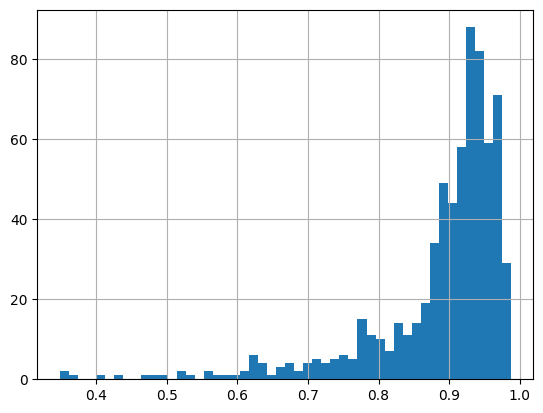

In [ ]:
##(Validation on Training Data)
w0, w1, w2, w3, w4 = model_no_age.params
TABLE_L['master_score_raw'] = (
    w0 +
    w1 * TABLE_L['months_score'] +
    w2 * TABLE_L['I_score'] +
    w3 * TABLE_L['slope_score'] +
    w4 * TABLE_L['CV_score']   )


TABLE_L['master_score'] = 1 / (1 + np.exp(-TABLE_L['master_score_raw']))

# validation checks
print('======target mean=======')
print(TABLE_L.groupby('target')['master_score'].mean())
print('=========================')
print("AUC:", roc_auc_score(TABLE_L['target'], TABLE_L['master_score']))
print('===============================')
TABLE_L['master_score'].hist(bins=50)

# TABLE_A

In [ ]:
## (DATA) all accounts
account_I1=account_I.copy()
age1=age.copy()
A=TRANS.copy()
# Cn:IN,OUT,B,P,IN/M,OUT/M,B/M,I
account_I1['I']=account_I1['B/M'] /account_I1['IN/M']
ACCOUNT_I=account_I1.merge(age1,how='inner',on='account_id')[['account_id','IN/M','Months_Count','owner_age','I']]
ACCOUNT_I=ACCOUNT_I.copy()
# Cn: b/time
A['date']=pd.to_datetime(A['date'])
A['year']=A['date'].dt.year
A['month']=A['date'].dt.month
A['IN'] = np.where(A['type'] == 'PRIJEM', A['amount'],  0)
A['OUT'] = np.where(A['type'].isin(['VYDAJ', 'VYBER']),A['amount'], 0)
A=A.sort_values(by=['account_id','year','month',])
trans_a=A.groupby(['account_id','year','month'])[['IN','OUT']].sum().reset_index()
trans_a['b']=trans_a['IN']-trans_a['OUT']
trans_a=trans_a[:].copy()
trans_a[:] # trans_a.to_csv("Cn-time.csv", index=False)
# slope
slp=trans_a.copy()
slp["month_index"] = slp.groupby("account_id").cumcount()
def calculate_slope_scaled_by_in(group):
    if len(group) < 2:
        return np.nan
    mean_IN = group["IN"].mean()
    if mean_IN == 0:
        return 0
    scaled_b = group["b"] / mean_IN
    slope, _ = np.polyfit(group["month_index"], scaled_b, 1)
    return slope
slp_a = (slp.groupby("account_id").apply(calculate_slope_scaled_by_in)
    .reset_index(name="s_slope"))
slp_a=slp_a.copy()
# variance
var = trans_a.groupby('account_id')['b'].var().reset_index()
var.columns = ['account_id', 'variance']
var=var.copy()
## RESULTS
table_a=ACCOUNT_I.merge(var,how='inner',on='account_id').merge(slp_a,how='inner',on='account_id')
table_a['CV'] = np.sqrt(table_a['variance']) / table_a['IN/M']
table_a=table_a.copy() # all
TABLE_A=table_a[['account_id','owner_age','Months_Count','I','CV','s_slope']]
TABLE_A

/tmp/ipykernel_695/4007299549.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slp_a = (slp.groupby("account_id").apply(calculate_slope_scaled_by_in)


,account_id,owner_age,Months_Count,I,CV,s_slope
0,1,28,45,0.069225,0.749784,-0.012891
1,2,53,70,0.026672,0.469251,-0.001476
2,3,42,17,0.295235,0.576272,-0.007573
3,4,79,34,0.175265,0.541610,-0.005934
4,5,69,19,0.288104,0.564641,-0.047359
...,...,...,...,...,...,...
4495,11333,56,55,0.034767,0.884433,-0.001833
4496,11349,53,43,0.017029,0.324286,-0.002646
4497,11359,30,50,0.049739,0.296415,0.000031
4498,11362,36,38,0.056293,0.351083,-0.001552


# ANALYIZE

/tmp/ipykernel_695/2049325884.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TABLE_A['months_score'] = (TABLE_A['Months_Count'] - months_A_mean) /  months_A_std


,account_id,master_score
3095,3255,0.988811
1574,1657,0.988107
3784,3982,0.987578
2886,3033,0.987469
2952,3105,0.987111
...,...,...
3672,3866,0.237097
3632,3823,0.232652
3817,4059,0.180432
3858,4204,0.157159


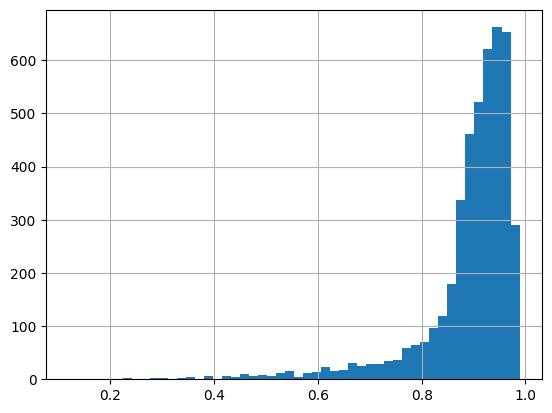

In [ ]:
## (Variable Preparation)

## (  TABLE_A scaled independently — KS test showed 4 of 5 variables differ
##    significantly from TABLE_L; locking scale to TABLE_L distorted scores
##    (PSI=0.737). Self-scaling fixes this (PSI=0.021).  )

# months
months_A_mean, months_A_std = TABLE_A['Months_Count'].mean(), TABLE_A['Months_Count'].std()
TABLE_A['months_score'] = (TABLE_A['Months_Count'] - months_A_mean) /  months_A_std
# I
I_A_min = TABLE_A['I'].min()
log_I_A = np.log1p(TABLE_A['I'] - I_A_min + 0.001)
I_A_mean, I_A_std = log_I_A.mean(), log_I_A.std()
TABLE_A['I_score'] = (log_I_A- I_A_mean ) / I_A_std
# Age
def age_score(age):
    if age < 25:        return (age/25) * 0.6
    elif age <= 50:     return 1.0
    elif age <= 65:     return (65-age)/15 * 0.8
    else:               return 0.1

TABLE_A['age_score_raw'] = TABLE_A['owner_age'].apply(age_score)
age_A_mean, age_A_std  =TABLE_A['age_score_raw'].mean() ,TABLE_A['age_score_raw'].std()
TABLE_A['age_score'] = (TABLE_A['age_score_raw'] - age_A_mean) /age_A_std
# slope
slope_A_lo, slope_A_hi = TABLE_A['s_slope'].quantile([0.02, 0.98])
slope_clipped_A = TABLE_A['s_slope'].clip(slope_A_lo, slope_A_hi)
slope_A_med = TABLE_A['s_slope'].median()
slope_A_iqr = TABLE_A['s_slope'].quantile(.75) - TABLE_A['s_slope'].quantile(.25)
TABLE_A['slope_score'] = (slope_clipped_A - slope_A_med) / slope_A_iqr
# CV
log_CV_A= np.log1p(TABLE_A['CV'])
CV_A_mean, CV_A_std = log_CV_A.mean(), log_CV_A.std()
TABLE_A['CV_score'] = ( log_CV_A - CV_A_mean ) / CV_A_std

### (Master_Score)
w0, w1, w2, w3, w4 = model_no_age.params
TABLE_A['master_score_raw'] = (
    w0 +
    w1 * TABLE_A['months_score'] +
    w2 * TABLE_A['I_score'] +
    w3 * TABLE_A['slope_score'] +
    w4 * TABLE_A['CV_score']   )

TABLE_A['master_score'] = 1 / (1 + np.exp(-TABLE_A['master_score_raw']))

TABLE_A=TABLE_A.sort_values('master_score', ascending=False)
TABLE_A[:]
TABLE_AA=TABLE_A[['account_id', 'master_score']]
TABLE_AA['master_score'].hist(bins=50)
TABLE_AA

In [ ]:
## (Validation)
def psi(expected, actual, buckets=10):
    breakpoints = np.linspace(0, 1, buckets+1)
    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    exp_pct = np.where(exp_pct == 0, 0.0001, exp_pct)
    act_pct = np.where(act_pct == 0, 0.0001, act_pct)
    return np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))

psi_value = psi(TABLE_L['master_score'], TABLE_AA['master_score'])
print(psi_value)

0.020079963522704747


# RESULTS :

In [ ]:
## (standared loan)
loan1=loan.copy()

std_amount=loan1['loanAmount'].median()
std_duration=loan1['LoanDuration'].median()

print('=========================')
print(f'std_amount = {std_amount} Kč ')
print(f'std_duration ={std_duration } months')
print('=========================')
## ( Capacity R )
capacity=account_I.copy()

capacity['capacity(R)']=(capacity['B/M']*std_duration)/std_amount

CAPACITY=capacity[['account_id','capacity(R)']]
print(f'capacity(R)= (B/M *{std_duration})/{std_amount}')

std_amount = 116928.0 Kč 
std_duration =36.0 months
capacity(R)= (B/M *36.0)/116928.0


In [ ]:
TABLE_A['I_rank'] = pd.qcut(TABLE_A['I_score'], q=[0, .33, .66, 1], labels=['Low', 'Medium', 'High'])
TABLE_A['CV_rank'] = pd.qcut(TABLE_A['CV_score'], q=[0, .33, .66, 1], labels=['Low', 'Medium', 'High'])

TABLE_F=CAPACITY.merge(TABLE_A,how='inner',on='account_id')[['account_id','capacity(R)','master_score','I_rank','CV_rank']]
TABLE_F  #TABLE_F.to_csv("RESULTS_TABLE.csv", index=False)

,account_id,capacity(R),master_score,I_rank,CV_rank
0,1,0.092036,0.880555,Medium,High
1,2,0.187350,0.965868,Low,Medium
2,3,0.925348,0.895444,High,Medium
3,4,0.305274,0.918752,High,Medium
4,5,0.455130,0.948316,High,Medium
...,...,...,...,...,...
4495,11333,0.326388,0.849805,Low,High
4496,11349,0.243327,0.937860,Low,Low
4497,11359,0.462974,0.959870,Low,Low
4498,11362,0.312095,0.929913,Low,Low
